<a href="https://colab.research.google.com/github/jeshurunjet/AUT_COMP809Assign1/blob/main/Copy_of_COMP809_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Title: Assignment 1:** Predicting Stroke Risk
#### **Course:** Postgraduate Diploma in Computer and Information Sciences
#### **Campus:** AUT Semester 1, 2026
#### **Student:** Jeshurun A. Sanchez
#### **Student ID:** 25316422

# **CONTEXT**

The World Health Organization estimates that stroke causes approximately 12 million deaths worldwide each year, and remains one of the leading causes of disability. Early identification of high-risk individuals can support timely preventive intervention. The dataset stroke data.csv (available on Canvas) contains medical records from 5,110 patients. (Please see file: COMP809_Assignment1Final.pdf for more context)

# **QUESTION 1A - DATA QUALITY ASSESSMENT**

**Load the dataset and perform a thorough data quality assessment. Identify and discuss
all data quality issues present. For each issue:**

In [ ]:
# ----- To make plots look nicer
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# ----- LOADING DATA -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/stroke_data.csv")

In [ ]:
# ----- DATA OVERVIEW -----

print("📊 Dataset Shape:")
display(pd.DataFrame(df.shape, index=["Rows", "Columns"], columns=["Count"]))

print("\n📋 Column Names:")
display(pd.DataFrame(df.columns, columns=["Columns"]))

print("\n🔎 Data Types:")
display(pd.DataFrame(df.dtypes, columns=["Data Type"]))

print("\n📈 Summary Statistics:")
display(df.describe())

print("\n👀 First 5 Rows:")
display(df.head())

The dataset contains 5,110 observations and 12 variables. Overall, the dataset is relatively clean, with only a small number of data quality issues identified.

- **Numerical variables:** age, avg_glucose_level, bmi
- **Categorical variables:** gender, ever_married, work_type, Residence_type, smoking_status
- **Binary variables:** hypertension, heart_disease, stroke
- **Identifier:** id

## **I. State what the issue is and quantify it (e.g. count and percentage)**

In [ ]:
# ----- Checking the data
summary_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

summary_df

,Missing Count,Missing %,Unique Values
id,0,0.00,5110
gender,0,0.00,3
age,0,0.00,104
hypertension,0,0.00,2
heart_disease,0,0.00,2
ever_married,0,0.00,2
work_type,0,0.00,5
Residence_type,0,0.00,2
avg_glucose_level,0,0.00,3979
bmi,201,3.93,418


In [ ]:
# ----- Checking for duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)



Number of duplicate rows: 0


#### **EXPLANATION**

The **BMI variable has missing values (201; ~3.93%)**, while the rest of the variables are complete. **No duplicate rows were found**, which means each observation represents its own unique value. These findings suggest that no further action is required for duplicate handling.

The number of unique values varies across variables and reflects their data types and roles. The ID variable contains 5,110 unique values, confirming that it is a unique identifier for each observation. Continuous variables such as age, average glucose level, and BMI exhibit a large number of unique values, which is expected given their numerical nature.

In contrast, categorical variables such as gender, hypertension, heart disease, and smoking status have a small number of unique categories. These values appear reasonable and consistent with their definitions, indicating no obvious data entry errors or unexpected categories.

Overall, the absence of duplicate records and the reasonable distribution of unique values suggest that the dataset is well-structured and suitable for further analysis.

**Feedback/Evaluation:**

In addition to missing BMI values and duplicate checks, other data-quality issues were identified. The gender variable contains an “Other” category with very few observations, which may create instability during modelling due to the extremely small sample size. This category was retained during EDA but should be treated carefully during modelling.

The smoking_status variable contains an “Unknown” category. This may represent missing or unrecorded smoking information rather than a true smoking group. Since it may still contain useful information, it was kept as a separate category rather than removed.

BMI also contains extreme values, with very high maximum values compared to the typical range. These values may represent valid medical outliers or possible data-entry issues. Therefore, they were examined visually before deciding whether to retain, cap, or remove them.

## **II. Propose and compare two different strategies to handle it**

Two possible strategies were considered: removal of incomplete values and imputation of missing values.

**Strategy 1: Removal of Missing Values**

One of the approaches is to remove all missing BMI values.

This strategy assumes that the missing data are Missing Completely At Random (MCAR), meaning that the probability of missingness is independent of both observed and unobserved variables. Under this assumption, removing missing values does not introduce bias.

However, this approach reduces the dataset size and may lead to loss of potentially useful information. If the missing values are not random, this method may introduce bias into the analysis and reduce the representativeness of the dataset.

**Strategy 2: Imputation of Missing Values**

The other approach is to impute the missing BMI values using statistical methods such as the mean or median.

This strategy assumes that the missing data can be reasonably estimated from the observed data. It preserves the full dataset and avoids the loss of information associated with deletion. However, simple imputation methods may reduce variability and weaken relationships between variables, potentially affecting model performance.

## **III. For each strategy, state the assumptions made, the potential impact on subsequent analysis, and your recommendation**

**Comparison and Recommendation**

In comparison, removal is simple but may lead to data loss and potential bias if the MCAR assumption is violated. Imputation retains all observations but may introduce estimation error. Given that the proportion of missing BMI values is relatively small (approximately 3.93%), imputation is preferred, as it preserves the dataset size while maintaining sufficient information for analysis.

**Treatment of ID Variable**

The ID variable was examined and confirmed to be a unique identifier for each observation. While it is useful for ensuring data integrity and detecting duplicates, it does not contain predictive information. Therefore, it will be retained during initial data checking but removed prior to modelling to avoid introducing irrelevant noise.

# **QUESTION 1(B): FEATURE ENGINEERING**

#### **FEATURES CODE**

In [ ]:
# ----- FEATURES -----

df_fe = df.copy()
df_fe["age_hypertension"] = df_fe["age"] * df_fe["hypertension"] # ----- Feature 1:  Interaction term
df_fe["log_glucose"] = np.log(df_fe["avg_glucose_level"] + 1) # ----- Feature 2: Transformation

def age_category(age): # ----- Feature 3: Categorise Age
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Old"

df_fe["age_group"] = df_fe["age"].apply(age_category)

def bmi_category(bmi): # ----- Feature 4: BMI Category
    if pd.isnull(bmi):
        return "Missing"
    elif bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_fe["bmi_group"] = df_fe["bmi"].apply(bmi_category)

df_fe["risk_score"] = ( # ----- Feature 5:  Extra
    df_fe["hypertension"] +
    df_fe["heart_disease"]
)
# ----- FEATURES - END -----

#### **FEATURES RESULT**

In [ ]:
# ----- FEATURE RESULTS -----
print(df_fe[[
    "age_hypertension",
    "log_glucose",
    "age_group",
    "bmi_group",
    "risk_score"
]].head())

print("\nAge * Hypertension vs Stroke:") # ----- Numeric feature
print(df_fe.groupby("stroke")["age_hypertension"].mean())

print("\nAge group distribution:") # ----- Categorical Feature Age
print(pd.crosstab(df_fe["age_group"], df_fe["stroke"], normalize="index"))

print("\nBMI group distribution:") # ----- Categorical Feature BMI
print(pd.crosstab(df_fe["bmi_group"], df_fe["stroke"], normalize="index"))

# ----- FEATURE RESULTS - END -----

   age_hypertension  log_glucose age_group bmi_group  risk_score
0               0.0     5.436731       Old     Obese           1
1               0.0     5.314240       Old   Missing           0
2               0.0     4.672081       Old     Obese           1
3               0.0     5.148831    Middle     Obese           0
4              79.0     5.165471       Old    Normal           1

Age * Hypertension vs Stroke:
stroke
0     5.423575
1    18.610442
Name: age_hypertension, dtype: float64

Age group distribution:
stroke            0         1
age_group                    
Middle     0.970257  0.029743
Old        0.868459  0.131541
Young      0.998680  0.001320

BMI group distribution:
stroke              0         1
bmi_group                      
Missing      0.800995  0.199005
Normal       0.971842  0.028158
Obese        0.948958  0.051042
Overweight   0.946771  0.053229
Underweight  0.997033  0.002967


## **Four Features to Predict Stroke + Extra**

Five new features were created from the original variables to improve the prediction of stroke. These features were designed to capture relationships between variables, reduce skewness, and make some variables easier to interpret. *The formulas used are based from the previous lectures (_see all the formulas used at the end of the document_).*

The feature **age_hypertension** was created by multiplying age and hypertension. This captures the combined effect of being older and having hypertension. The average value is much higher for stroke patients (18.61) compared to non-stroke patients (5.42), suggesting higher risk.

The feature **log_glucose** was created by applying a log transformation to average glucose level. This helps reduce the effect of extreme values and makes the data more stable for modelling.

The feature **age_group** categorises age into Young, Middle, and Old. This helps show patterns more clearly. Stroke rates increase from 0.13% (Young) to 2.97% (Middle) and 13.15% (Old), showing that age is strongly related to stroke.

The feature **bmi_group** categorises BMI into Underweight, Normal, Overweight, Obese, and Missing. This helps capture health risk levels. Stroke rates are higher in the Overweight and Obese groups, and the Missing category also shows higher risk.

The feature **risk_score** was created by adding hypertension and heart disease. This represents the number of risk factors a person has, where more conditions increase stroke risk.

Overall, these features include an interaction term, a transformation, and grouped variables. The clear differences between stroke and non-stroke groups show that these features are useful and can help improve the model.

# **QUESTION 1(C): MISSING DATA INVESTIGATION**

## **I. Missingness Mechanism**

#### **CODES FOR INVESTIGATING MISSING DATA**

In [ ]:
# ----- MISSING DATA INVESTIGATION -----

df_fe["bmi_missing"] = df_fe["bmi"].isnull().astype(int)

print("\nAverage age by BMI missing:") # ----- Averaging ages
print(df_fe.groupby("bmi_missing")["age"].mean())

print("\nStroke rate by BMI missing:") # ----- Stroke rates
print(df_fe.groupby("bmi_missing")["stroke"].mean())

print("\nHypertension rate by BMI missing:") # Hypertension rates
print(df_fe.groupby("bmi_missing")["hypertension"].mean())

# ----- MISSING DATA INVESTIGATION - END -----


Average age by BMI missing:
bmi_missing
0    42.865374
1    52.049154
Name: age, dtype: float64

Stroke rate by BMI missing:
bmi_missing
0    0.042575
1    0.199005
Name: stroke, dtype: float64

Hypertension rate by BMI missing:
bmi_missing
0    0.091872
1    0.233831
Name: hypertension, dtype: float64


#### **EXPLANATION**

The BMI variable contains missing values, which were examined prior to selecting an imputation method. To determine the likely mechanism of missingness, individuals with and without missing BMI values were compared using observed characteristics such as age, stroke status, and hypertension. This comparison was conducted using **Groupby analysis**, which was pre-approved on the class online discussion on Canvas, to summarise differences between the two groups.

The results show clear differences between the two groups. Patients with missing BMI values are older (average age 52.05 vs 42.87), have a higher stroke rate (19.90% vs 4.26%), and a higher prevalence of hypertension (23.38% vs 9.19%) compared to those with observed BMI. Since the probability of missingness is associated with observed variables, the data is unlikely to be Missing Completely At Random (MCAR). Instead, it is most consistent with Missing At Random (MAR), as missingness depends on other observed characteristics. There is no evidence to suggest Missing Not At Random (MNAR), as this would require dependence on the unobserved BMI values themselves.

## **II. Imputation Methods**

In [ ]:
# ----- IMPUTATION METHODS -----

# ----- 1st Imputation - Mean/Median
# Mean imputation
df_mean = df_fe.copy()
mean_bmi = df_mean["bmi"].mean()
df_mean["bmi"] = df_mean["bmi"].fillna(mean_bmi)

# Median imputation
df_median = df_fe.copy()
median_bmi = df_median["bmi"].median()
df_median["bmi"] = df_median["bmi"].fillna(median_bmi)

# ----- 2nd Imputation - Regression-based
from sklearn.linear_model import LinearRegression

# ----- Use only rows where BMI exists
train_data = df_fe[df_fe["bmi"].notnull()]

X_bmi_train = train_data[["age", "avg_glucose_level", "hypertension", "heart_disease"]]
y_bmi_train = train_data["bmi"]

# ----- Train model
model = LinearRegression()
model.fit(X_bmi_train, y_bmi_train)

# ----- Predict missing BMI
missing_data = df_fe[df_fe["bmi"].isnull()]
X_missing = missing_data[["age", "avg_glucose_level", "hypertension", "heart_disease"]]

predicted_bmi = model.predict(X_missing)

# ----- Fill values
df_regression = df_fe.copy()
df_regression.loc[df_regression["bmi"].isnull(), "bmi"] = predicted_bmi

# ----- 3rd Imputation - Group-based
df_group = df_fe.copy()

group_median = df_group.groupby("gender")["bmi"].transform("median")
df_group["bmi"] = df_group["bmi"].fillna(group_median)

# ----- Comparing Distributions
print("\nOriginal BMI:")
print(df_fe["bmi"].describe())

print("\nMean Imputed BMI:")
print(df_mean["bmi"].describe())

print("\nMedian Imputed BMI:")
print(df_median["bmi"].describe())

print("\nRegression Imputed BMI:")
print(df_regression["bmi"].describe())

print("\nGroup Imputed BMI:")
print(df_group["bmi"].describe())
# ----- IMPUTATION METHODS - END -----


Original BMI:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

Mean Imputed BMI:
count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

Median Imputed BMI:
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

Regression Imputed BMI:
count    5110.000000
mean       28.947636
std         7.724395
min        10.300000
25%        23.800000
50%        28.200000
75%        33.000000
max        97.600000
Name: bmi, dtype: float64

Group Imputed BMI:
count    5110.000000
mean       28.862446
std         7.699752
min        10.300000
25%        23.800000
50%        28.10000

#### **EXPLANATION**

Three imputation strategies were implemented and compared.

The first approach was single-value imputation using the **mean and median**. These methods are simple but do not preserve relationships between variables and reduce variability. This is evident from the decrease in standard deviation from 7.85 in the original data to approximately 7.70 after both mean and median imputation, indicating a more concentrated distribution.

The second approach was **regression-based imputation**, where BMI was predicted using a linear regression model with age, average glucose level, hypertension, and heart disease as predictors. This method better preserves relationships between variables. The resulting distribution closely matches the original, with a mean of 28.95 (compared to 28.89) and a standard deviation of 7.72, which is closer to the original variability than the single-value methods.

The third approach was **group-based imputation** using the median BMI within gender groups. While this method introduces some group-level variation, the resulting distribution is still similar to median imputation, with reduced variability and limited ability to capture relationships between multiple variables.

## **III. Visualization**

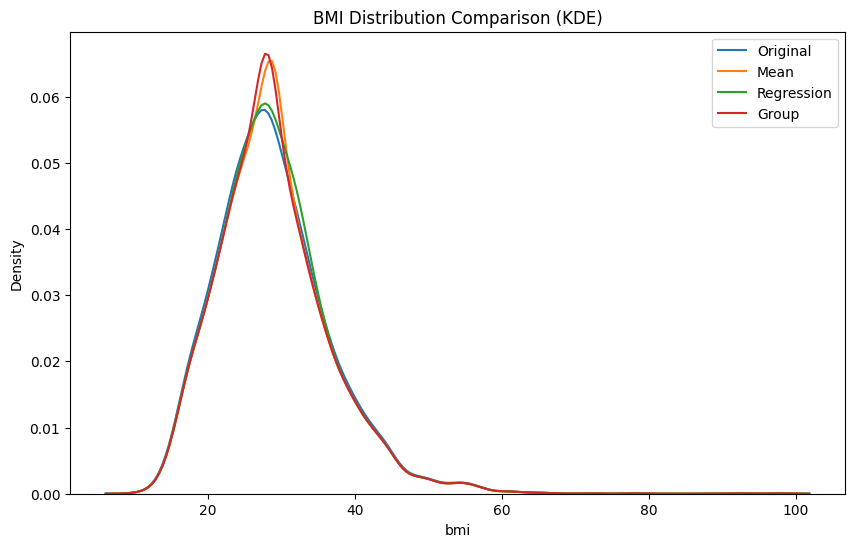

In [ ]:
# ----- Visualization: PLOT using KDE
plt.figure(figsize=(10,6))

sns.kdeplot(df_fe["bmi"].dropna(), label="Original")
sns.kdeplot(df_mean["bmi"], label="Mean")
sns.kdeplot(df_regression["bmi"], label="Regression")
sns.kdeplot(df_group["bmi"], label="Group")

plt.title("BMI Distribution Comparison (KDE)")
plt.legend()

plt.show()

#### **EXPLANATION**

The imputed distributions were compared with the original using summary statistics and kernel density plots. Mean and median imputation produced smoother distributions with less spread, while regression imputation more closely followed the original distribution and preserved variability.

Overall, the missingness of BMI is most consistent with MAR. Among the methods tested, regression-based imputation provides the best balance between plausibility and preservation of the original data structure. Therefore, regression imputation is selected for subsequent analysis.

# **QUESTION 1(D): EXPLORATORY DATA ANALYSIS AND MULTICOLLINEARITY**

Exploratory data analysis was conducted to examine the relationship between stroke and key predictors, including age, average glucose level, and BMI. The analysis was performed using the dataset after applying regression-based imputation for missing BMI values.

---------- QUESTION 1D DATA ANALYSIS AND MULTICOLLINEARITY ----------


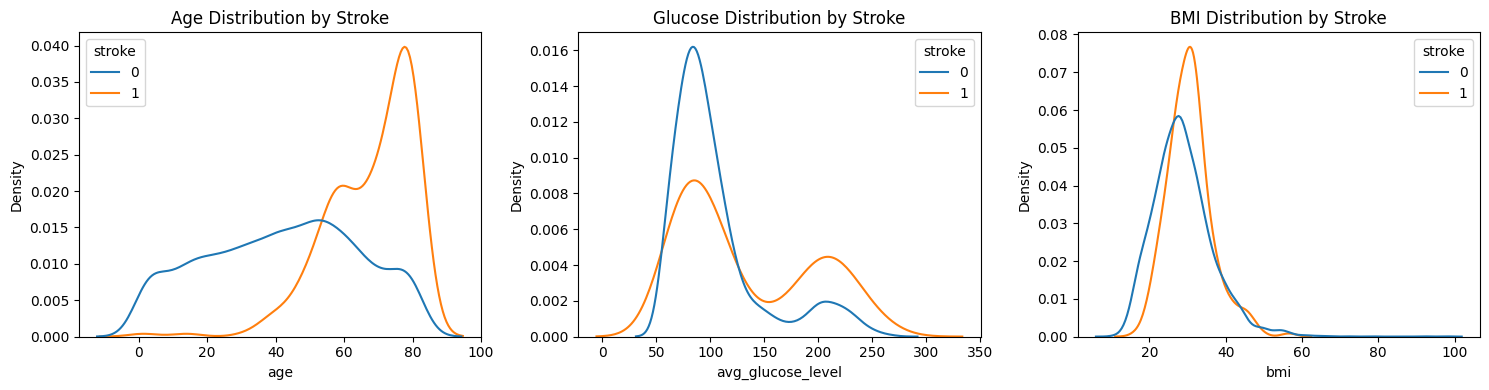

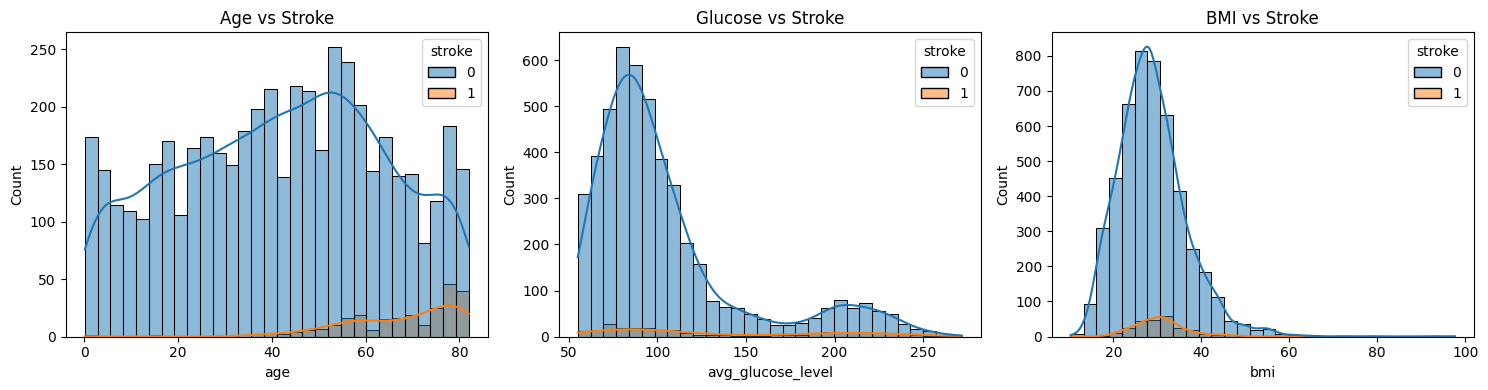

In [ ]:
# ---------- QUESTION 1D DATA ANALYSIS AND MULTICOLLINEARITY ----------
print("---------- QUESTION 1D DATA ANALYSIS AND MULTICOLLINEARITY ----------")

# ----- VISUALIZATIONS -----

# ----- using KDE
df_final = df_regression.copy()
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.kdeplot(data=df_final, x="age", hue="stroke", common_norm=False)
plt.title("Age Distribution by Stroke")

plt.subplot(1,3,2)
sns.kdeplot(data=df_final, x="avg_glucose_level", hue="stroke", common_norm=False)
plt.title("Glucose Distribution by Stroke")

plt.subplot(1,3,3)
sns.kdeplot(data=df_final, x="bmi", hue="stroke", common_norm=False)
plt.title("BMI Distribution by Stroke")

plt.tight_layout()
plt.show()

# ----- using HISTOGRAMS
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(data=df_final, x="age", hue="stroke", bins=30, kde=True)
plt.title("Age vs Stroke")

plt.subplot(1,3,2)
sns.histplot(data=df_final, x="avg_glucose_level", hue="stroke", bins=30, kde=True)
plt.title("Glucose vs Stroke")

plt.subplot(1,3,3)
sns.histplot(data=df_final, x="bmi", hue="stroke", bins=30, kde=True)
plt.title("BMI vs Stroke")

plt.tight_layout()
plt.show()

# ----- VISUALIZATIONS - END -----

#### **EXPLANATION**

In these plots, we can clearly see that age has the strongest association with stroke, as stroke patients are generally significantly older than non-stroke patients. Average glucose level shows a moderate relationship, with higher values observed among stroke patients. In contrast, BMI demonstrates a weaker relationship, with substantial overlap between stroke and non-stroke groups, suggesting limited discriminative power when used alone.

### **CORRELATION AND VIF**

In [ ]:
# ----- CORRELATION AND VIF -----

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select variables
X_vif = df_regression[["age", "avg_glucose_level", "bmi"]]

# Correlation matrix
corr = X_vif.corr()

print(" Correlation Matrix:")
display(corr.style.background_gradient(cmap="coolwarm").format("{:.2f}"))

# VIF calculation
vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
})

print("\n Variance Inflation Factor (VIF):")
display(vif_data.style.format({"VIF": "{:.2f}"}))

# ----- END -----

 Correlation Matrix:


,age,avg_glucose_level,bmi
age,1.00,0.24,0.34
avg_glucose_level,0.24,1.00,0.18
bmi,0.34,0.18,1.00



 Variance Inflation Factor (VIF):


,Feature,VIF
0,age,5.42
1,avg_glucose_level,5.99
2,bmi,8.05


#### **EXPLANATION**

To further assess relationships among predictors, a correlation matrix was computed. All pairwise correlations are relatively low, with the highest correlation observed between age and BMI (r = 0.34), followed by age and average glucose level (r = 0.24) and BMI and glucose level (r = 0.18). Since none of these values exceed the common threshold of |r| > 0.6, there is no evidence of strong linear relationships between the variables. This indicates that multicollinearity is not severe based on correlation alone.

Variance Inflation Factor (VIF) was also calculated to assess multicollinearity more comprehensively. The VIF values were 5.42 for age, 5.99 for average glucose level, and 8.05 for BMI. These results indicate moderate multicollinearity, particularly for BMI, which exceeds the commonly used threshold of 5. However, the values are not excessively high (e.g., above 10), suggesting that multicollinearity is present but not critical.

All variables were retained for further analysis. This decision is justified because the correlations are relatively low, and each variable provides meaningful information for predicting stroke. If multicollinearity becomes problematic in later modelling stages, it can be addressed using techniques such as feature selection or regularisation methods (e.g., Ridge or Lasso regression).

# **QUESTION 2(A): BASELINE LOGISTIC REGRESSION MODELS**

Three logistic regression models were developed to predict stroke risk using a 70/30 train-test split with random state set to 42, as required. For this baseline analysis, only the original variables were used, and engineered features from Question 1(b) were excluded to ensure a fair comparison. This baseline setup allows for later comparison with improved models that address class imbalance and other limitations.


#### **PREPARING THE DATA**

In [ ]:
# ----- DATA PREP & TRAINING -----

# ----- dropping the ID
df_model = df_regression.copy()
df_model = df_model.drop(columns=[
    "age_hypertension",
    "log_glucose",
    "age_group",
    "bmi_group",
    "risk_score",
    "bmi_missing",
    "id"
], errors="ignore")
df_model = df_model.drop(columns=["id"], errors="ignore")

# ----- separating x and y
X_model = df_model.drop(columns=["stroke"])
y_model = df_model["stroke"]

# ----- encoding categorical variables
X_model = pd.get_dummies(X_model, drop_first=True)

# ----- TRAINING TEST SPLIT
from sklearn.model_selection import train_test_split

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(
    X_model, y_model,
    test_size=0.3,
    random_state=42
)

print("Training set size:", X_train_model.shape)
print("Test set size:", X_test_model.shape)

print("\nStroke distribution (train):")
print(y_train_model.value_counts(normalize=True))

print("\nStroke distribution (test):")
print(y_test_model.value_counts(normalize=True))

# ----- DATA PREP & TRAINING - END -----

Training set size: (3577, 16)
Test set size: (1533, 16)

Stroke distribution (train):
stroke
0    0.95527
1    0.04473
Name: proportion, dtype: float64

Stroke distribution (test):
stroke
0    0.941944
1    0.058056
Name: proportion, dtype: float64


In [ ]:
# ----- STORING DATA ----- For Visuals & Plots Later
# ----- Table
results = []

def add_result(name, accuracy, precision, recall, specificity, f1, auc):
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "AUC": auc
    })
# ----- STORING DATA - END

## **I. BASIC LOGISTIC REGRESSION**

In [ ]:
# ----- MODEL 1 BASIC LOGISTIC REGRESSION -----
print("----- BASIC LOGISTIC REGRESSION -----")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score

# ----- Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

# ----- Build model
model_basic = LogisticRegression(max_iter=1000)
model_basic.fit(X_train_scaled, y_train_model)

# ----- Predictions
y_pred_basic = model_basic.predict(X_test_scaled)
y_prob_basic = model_basic.predict_proba(X_test_scaled)[:, 1]

# ----- Confusion Matrix
cm_basic = confusion_matrix(y_test_model, y_pred_basic)
roc_auc_score(y_test_model, y_prob_basic)
tn, fp, fn, tp = cm_basic.ravel()

print("Confusion Matrix:")
print(cm_basic)

# ----- Metrics
accuracy_basic = (tp + tn) / (tp + tn + fp + fn)
precision_basic = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_basic = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_basic = tn / (tn + fp)
f1_basic = 2 * (precision_basic * recall_basic) / (precision_basic + recall_basic) if (precision_basic + recall_basic) > 0 else 0
auc_basic = roc_auc_score(y_test_model, y_prob_basic)

print("\nMetrics:")
print("Accuracy:", accuracy_basic)
print("Precision:", precision_basic)
print("Recall:", recall_basic)
print("Specificity:", specificity_basic)
print("F1-score:", f1_basic)
print("AUC:", auc_basic)

# ----- Basic Model Result >> Table
add_result("Basic",
           accuracy_basic, precision_basic, recall_basic, specificity_basic, f1_basic, auc_basic)

# ----- MODEL 1 BASIC LOGISTIC REGRESSION - END -----

----- BASIC LOGISTIC REGRESSION -----
Confusion Matrix:
[[1444    0]
 [  88    1]]

Metrics:
Accuracy: 0.9425962165688193
Precision: 1.0
Recall: 0.011235955056179775
Specificity: 1.0
F1-score: 0.02222222222222222
AUC: 0.8403934140496124


#### **EXPLANATION**

The first model was a basic logistic regression model using default parameters. This model achieved a high accuracy of 94.06%, but this result is misleading due to the severe class imbalance. The model predicted almost all observations as non-stroke, resulting in a very high specificity (99.79%) but extremely poor recall (1.12%), meaning it failed to correctly identify most stroke cases. The F1-score (0.02) is also very low, reflecting the poor balance between precision and recall. Despite this, the AUC value of 0.85 indicates that the model is capable of distinguishing between classes when considering probability outputs rather than fixed classification thresholds.

## **II. CLASS-WEIGHTED LOGISTIC REGRESSION**

In [ ]:
# ----- MODEL 2 CLASS-WEIGHTED LOGISTIC REGRESSION -----
print("----- CLASS-WEIGHTED LOGISTIC REGRESSION -----")

# ----- Build Model
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced")
model_weighted.fit(X_train_scaled, y_train_model)

# ----- Predictions
y_pred_w = model_weighted.predict(X_test_scaled)
y_prob_w = model_weighted.predict_proba(X_test_scaled)[:,1]

# ----- Metrics
cm_weighted = confusion_matrix(y_test_model, y_pred_w)
tn, fp, fn, tp = cm_weighted.ravel()

print("Confusion Matrix:")
print(cm_weighted)

accuracy_class = (tp + tn) / (tp + tn + fp + fn)
precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_class = tn / (tn + fp)
f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
auc_class = roc_auc_score(y_test_model, y_prob_w)

print("\nMetrics:")
print("Accuracy:", accuracy_class)
print("Precision:", precision_class)
print("Recall:", recall_class)
print("Specificity:", specificity_class)
print("F1-score:", f1_class)
print("AUC:", auc_class)

# ----- Class-weighted Model Result >> Table
add_result("Class-weighted",
           accuracy_class, precision_class, recall_class, specificity_class, f1_class, auc_class)

# ----- MODEL 2 CLASS-WEIGHTED LOGISTIC REGRESSION - END -----

----- CLASS-WEIGHTED LOGISTIC REGRESSION -----
Confusion Matrix:
[[1081  363]
 [  23   66]]

Metrics:
Accuracy: 0.7482061317677756
Precision: 0.15384615384615385
Recall: 0.7415730337078652
Specificity: 0.7486149584487535
F1-score: 0.25482625482625487
AUC: 0.8414360857792025


#### **EXPLANATION**

The second model incorporated class weighting using class_weight="balanced", which adjusts the loss function to penalise misclassification of the minority class more heavily. This resulted in a substantial improvement in the model’s ability to detect stroke cases, with recall increasing dramatically to 74.16%. However, this improvement came at the cost of increased false positives, leading to a decrease in precision (15.38%) and specificity (74.87%), as well as a lower overall accuracy (74.82%). The F1-score improved to 0.25, indicating a better balance between precision and recall. The AUC remained similar (0.84), suggesting that the underlying ranking ability of the model did not change significantly, but the classification threshold and decision boundary shifted due to the class weighting.

## **III. REGULARISED LOGISTIC REGRESSION**

In [ ]:
# ----- MODEL 3 REGULARISED LOGISTIC REGRESSION -----
print("----- REGULARISED LOGISTIC REGRESSION -----")

# ----- Build Model
model_reg = LogisticRegression(
    max_iter=1000,  # Ridge
    C=1.0           # regularization strength
)

model_reg.fit(X_train_scaled, y_train_model)

# ----- Prediction
y_pred_r = model_reg.predict(X_test_scaled)
y_prob_r = model_reg.predict_proba(X_test_scaled)[:,1]

# ----- Metrics
cm_regular = confusion_matrix(y_test_model, y_pred_r)
tn, fp, fn, tp = cm_regular.ravel()

print("Confusion Matrix:")
print(cm_regular)

accuracy_regular = (tp + tn) / (tp + tn + fp + fn)
precision_regular = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_regular = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_regular = tn / (tn + fp)
f1_regular = 2 * (precision_regular * recall_regular) / (precision_regular + recall_regular) if (precision_regular + recall_regular) > 0 else 0
auc_regular = roc_auc_score(y_test_model, y_prob_r)

print("\nMetrics:")
print("Accuracy:", accuracy_regular)
print("Precision:", precision_regular)
print("Recall:", recall_regular)
print("Specificity:", specificity_regular)
print("F1-score:", f1_regular)
print("AUC:", auc_regular)

# ----- Regularised Model Result >> Table
add_result("Regularised",
           accuracy_regular, precision_regular, recall_regular, specificity_regular, f1_regular, auc_regular)

# ----- MODEL 3 REGULARISED LOGISTIC REGRESSION - END -----

----- REGULARISED LOGISTIC REGRESSION -----
Confusion Matrix:
[[1444    0]
 [  88    1]]

Metrics:
Accuracy: 0.9425962165688193
Precision: 1.0
Recall: 0.011235955056179775
Specificity: 1.0
F1-score: 0.02222222222222222
AUC: 0.8403934140496124


#### **EXPLANATION**

The third model applied L2 (Ridge) regularisation, which penalises large coefficients by shrinking them towards zero. This helps reduce overfitting and stabilise the model, particularly in the presence of multicollinearity. However, in this case, the regularised model produced results identical to the basic model, with no improvement in recall or other performance metrics. This suggests that overfitting or coefficient instability was not a major issue in the dataset, and that class imbalance remains the dominant challenge affecting model performance.


### SUMMARY TABLE (LOGISTIC REGRESSION COMPARISON)

In [ ]:
results_df = pd.DataFrame([
    ["Basic", accuracy_basic, precision_basic, recall_basic, specificity_basic, f1_basic, auc_basic],
    ["Class-weighted", accuracy_class, precision_class, recall_class, specificity_class, f1_class, auc_class],
    ["Regularised", accuracy_regular, precision_regular, recall_regular, specificity_regular, f1_regular, auc_regular],
], columns=[
    "Model", "Accuracy", "Precision", "Recall", "Specificity", "F1-score", "AUC"
])

# sort by recall
results_df = results_df.sort_values(by="Recall", ascending=False)

display(results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "Specificity": "{:.3f}",
    "F1-score": "{:.3f}",
    "AUC": "{:.3f}"
}))

,Model,Accuracy,Precision,Recall,Specificity,F1-score,AUC
1,Class-weighted,0.748,0.154,0.742,0.749,0.255,0.841
0,Basic,0.943,1.000,0.011,1.000,0.022,0.840
2,Regularised,0.943,1.000,0.011,1.000,0.022,0.840


#### **EXPLANATION**

The differences in performance between the models are primarily driven by the class imbalance in the dataset. The basic and regularised models prioritise overall accuracy and therefore favour the majority class, resulting in poor detection of stroke cases. In contrast, the class-weighted model shifts the decision boundary to better capture the minority class, significantly improving recall at the expense of precision and accuracy. This trade-off highlights the importance of selecting evaluation metrics carefully in imbalanced classification problems, where recall and F1-score are often more informative than accuracy.

In summary, while the basic and regularised models achieve high accuracy, they perform poorly in identifying stroke cases. The class-weighted model provides a more balanced performance and is better suited for this task, as correctly identifying high-risk patients is more critical than minimising false positives in a healthcare context.   

## **QUESTION 2(B): ADDRESSING CLASS IMBALANCE**

## **I. RANDOM UNDERSAMPLING**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE

# ----- UNDERSAMPLING -----
print("----- UNDERSAMPLING -----")

# ----- Build Model
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train_model)

model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_train_under, y_train_under)

# ---- Predictions
y_pred_u = model_under.predict(X_test_scaled)
y_prob_u = model_under.predict_proba(X_test_scaled)[:,1]

# ----- Confusion matrix
cm_under = confusion_matrix(y_test_model, y_pred_u)
tn, fp, fn, tp = cm_under.ravel()

print("Confusion Matrix:")
print(cm_under)

# ------ Metrics
accuracy_under = (tp + tn) / (tp + tn + fp + fn)
precision_under = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_under = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_under = tn / (tn + fp)
f1_under = 2 * (precision_under * recall_under) / (precision_under + recall_under) if (precision_under + recall_under) > 0 else 0
auc_under = roc_auc_score(y_test_model, y_prob_u)

print("\nMetrics:")
print("Accuracy:", accuracy_under)
print("Precision:", precision_under)
print("Recall:", recall_under)
print("Specificity:", specificity_under)
print("F1-score:", f1_under)
print("AUC:", auc_under)

# ----- UnderSampling Model Result >> Table
add_result("Undersampling",
           accuracy_under, precision_under, recall_under, specificity_under, f1_under, auc_under)

# ----- UNDERSAMPLING - END -----

----- UNDERSAMPLING -----
Confusion Matrix:
[[1075  369]
 [  25   64]]

Metrics:
Accuracy: 0.7429876060013046
Precision: 0.14780600461893764
Recall: 0.7191011235955056
Specificity: 0.7444598337950139
F1-score: 0.24521072796934867
AUC: 0.8331569610009649


## **II. OVERSAMPLING**

In [ ]:
# ----- OVERSAMPLING -----
print("----- OVERSAMPLING -----")

# ----- Build
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train_scaled, y_train_model)

model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_train_over, y_train_over)

# ----- Predictions
y_pred_o = model_over.predict(X_test_scaled)
y_prob_o = model_over.predict_proba(X_test_scaled)[:,1]

# ----- Confusion matrix
cm_over = confusion_matrix(y_test_model, y_pred_o)
tn, fp, fn, tp = cm_over.ravel()

print("Confusion Matrix:")
print(cm_over)

# ----- Metrics
accuracy_over = (tp + tn) / (tp + tn + fp + fn)
precision_over = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_over = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_over = tn / (tn + fp)
f1_over = 2 * (precision_over * recall_over) / (precision_over + recall_over) if (precision_over + recall_over) > 0 else 0
auc_over = roc_auc_score(y_test_model, y_prob_o)

print("\nMetrics:")
print("Accuracy:", accuracy_over)
print("Precision:", precision_over)
print("Recall:", recall_over)
print("Specificity:", specificity_over)
print("F1-score:", f1_over)
print("AUC:", auc_over)

# ----- OverSampling Model Result >> Table
add_result("Oversampling",
           accuracy_over, precision_over, recall_over, specificity_over, f1_over, auc_over)

# ----- OVERSAMPLING - END -----

----- OVERSAMPLING -----
Confusion Matrix:
[[1085  359]
 [  23   66]]

Metrics:
Accuracy: 0.7508153946510111
Precision: 0.15529411764705883
Recall: 0.7415730337078652
Specificity: 0.7513850415512465
F1-score: 0.2568093385214008
AUC: 0.8408135951943727


## **III. SMOTE**

In [ ]:
# ----- SMOTE - Synthetic Minority Over-sampling Technique -----
print("----- SMOTE -----")

# ----- Build Model
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_model)

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# ----- Predictions
y_pred_s = model_smote.predict(X_test_scaled)
y_prob_s = model_smote.predict_proba(X_test_scaled)[:,1]

# ----- Confusion matrix
cm_smote = confusion_matrix(y_test_model, y_pred_s)
tn, fp, fn, tp = cm_smote.ravel()

print("Confusion Matrix:")
print(cm_smote)

# ----- Metrics
accuracy_smote = (tp + tn) / (tp + tn + fp + fn)
precision_smote = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_smote = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_smote = tn / (tn + fp)
f1_smote = 2 * (precision_smote * recall_smote) / (precision_smote + recall_smote) if (precision_smote + recall_smote) > 0 else 0
auc_smote = roc_auc_score(y_test_model, y_prob_s)

print("\nMetrics:")
print("Accuracy:", accuracy_smote)
print("Precision:", precision_smote)
print("Recall:", recall_smote)
print("Specificity:", specificity_smote)
print("F1-score:", f1_smote)
print("AUC:", auc_smote)

# ----- SMOTE Model Result >> Table
add_result("SMOTE",
           accuracy_smote, precision_smote, recall_smote, specificity_smote, f1_smote, auc_smote)

# ----- SMOTE - Synthetic Minority Over-sampling Technique - END -----

----- SMOTE -----
Confusion Matrix:
[[1080  364]
 [  23   66]]

Metrics:
Accuracy: 0.7475538160469667
Precision: 0.15348837209302327
Recall: 0.7415730337078652
Specificity: 0.7479224376731302
F1-score: 0.2543352601156069
AUC: 0.8396542064801269


### SUMMARY TABLE (RESAMPLING METHODS COMPARISON)

In [ ]:
# ----- RESAMPLING METHODS COMPARISON -----
resampling_df = pd.DataFrame([
    ["Undersampling", accuracy_under, precision_under, recall_under, specificity_under, f1_under, auc_under],
    ["Oversampling", accuracy_over, precision_over, recall_over, specificity_over, f1_over, auc_over],
    ["SMOTE", accuracy_smote, precision_smote, recall_smote, specificity_smote, f1_smote, auc_smote]
], columns=[
    "Method", "Accuracy", "Precision", "Recall", "Specificity", "F1-score", "AUC"
])

display(
    resampling_df.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "Specificity": "{:.3f}",
        "F1-score": "{:.3f}",
        "AUC": "{:.3f}"
    })
    .highlight_max(color="lightgreen")
)

,Method,Accuracy,Precision,Recall,Specificity,F1-score,AUC
0,Undersampling,0.743,0.148,0.719,0.744,0.245,0.833
1,Oversampling,0.751,0.155,0.742,0.751,0.257,0.841
2,SMOTE,0.748,0.153,0.742,0.748,0.254,0.840


#### **EXPLANATION**

The stroke dataset is highly imbalanced, with only approximately 5% of observations belonging to the positive class. To address this issue, three resampling strategies were implemented: random undersampling, random oversampling, and SMOTE. Logistic regression models were trained on the resampled training data and evaluated on the original test set.

The results show that all three resampling techniques significantly improved recall compared to the baseline model (from approximately 1.12% to between 71.91% and 74.16%). This indicates that resampling methods are effective at identifying stroke cases. However, this improvement comes at the cost of lower precision (around 14.8%–15.5%) and reduced overall accuracy (around 74%–75%), due to an increase in false positives.

Among the resampling methods, random oversampling performed slightly better overall, achieving the highest accuracy (~75.1%), precision (~15.5%), F1-score (~0.257), and AUC (~0.841). SMOTE produced very similar results but was marginally lower across these metrics, while undersampling performed the worst among the three.

In a stroke screening context, recall is the most important metric because missing a true stroke case (false negative) can have severe consequences. Therefore, although oversampling performs slightly better numerically, all three methods are appropriate as they significantly improve detection of stroke cases.

# **QUESTION 2(C): MODEL IMPROVEMENT**

Several approaches were explored to improve the baseline logistic regression models, with the primary goal of increasing the detection of stroke cases while maintaining reasonable overall performance.

### Resampling Techniques
Resampling methods, including undersampling, oversampling, and SMOTE, were applied to address class imbalance. These approaches significantly improved recall from approximately 1.12% in the baseline model to around 74.16%. However, this improvement came at the cost of reduced precision and accuracy due to an increase in false positives. Based on the results, random oversampling is selected as the best-performing approach, as it achieves slightly higher accuracy, precision, F1-score, and AUC compared to the other resampling methods. While SMOTE produces very similar performance, oversampling provides marginally better overall results in this case. Therefore, the oversampling model is chosen as the final model for further evaluation.

### Class-Weighted Logistic Regression
Class-weighted logistic regression was also tested, where the minority class was penalised more heavily during training. This approach produced results similar to resampling, with recall increasing to approximately 74.16% while maintaining a comparable balance across other metrics. This demonstrates that adjusting the loss function can be as effective as resampling for handling class imbalance.

### Threshold Tuning

In [ ]:
y_prob = model_weighted.predict_proba(X_test_scaled)[:,1]

# ----- THRESHOLD 0.2
threshold_02 = 0.2
y_pred_02 = (y_prob >= threshold_02).astype(int)

cm_02 = confusion_matrix(y_test_model, y_pred_02)
tn, fp, fn, tp = cm_02.ravel()

recall_02 = tp / (tp + fn)
precision_02 = tp / (tp + fp)
f1_02 = 2 * (precision_02 * recall_02) / (precision_02 + recall_02)

print("\nThreshold:", threshold_02)
print("Recall:", recall_02)
print("Precision:", precision_02)
print("F1:", f1_02)

# ----- THRESHOLD 0.3
threshold_03 = 0.3
y_pred_03 = (y_prob >= threshold_03).astype(int)

cm_03 = confusion_matrix(y_test_model, y_pred_03)
tn, fp, fn, tp = cm_03.ravel()

recall_03 = tp / (tp + fn)
precision_03 = tp / (tp + fp)
f1_03 = 2 * (precision_03 * recall_03) / (precision_03 + recall_03)

print("\nThreshold:", threshold_03)
print("Recall:", recall_03)
print("Precision:", precision_03)
print("F1:", f1_03)

# ---------- QUESTION 2C MODEL IMPROVEMENT - END ----------


Threshold: 0.2
Recall: 0.9550561797752809
Precision: 0.1051980198019802
F1: 0.18952062430323297

Threshold: 0.3
Recall: 0.9101123595505618
Precision: 0.11982248520710059
F1: 0.21176470588235294


#### **EXPLANATION**

To further improve the model for a screening context, two different classification thresholds were tested. Lowering the threshold increases recall, but reduces precision and specificity.

From the results above, at a threshold of 0.3, the model achieves a recall of approximately 0.91, meaning it correctly identifies around 91% of stroke cases. However, precision drops to about 0.12, showing that there are more false positives. The F1-score at this threshold is approximately 0.21.

At a lower threshold of 0.2, recall increases further to approximately 0.96, but precision decreases to about 0.105, and the F1-score slightly drops to around 0.19. This suggests diminishing returns, as the improvement in recall is small compared to the loss in precision.

Therefore, a threshold of 0.3 is recommended, as it provides a good balance between high recall and acceptable precision for a screening setting.

### Regularisation
Regularisation (L2/Ridge) was also tested but did not improve the model performance. The results were the same as the basic logistic regression model, suggesting that overfitting is not a major issue and that class imbalance is the main challenge.

### Final Model Selection
Overall, improving performance in this task mainly depends on handling class imbalance and adjusting the classification threshold, rather than increasing model complexity.

The final model selected is the class-weighted logistic regression model with a threshold of 0.3. This model achieves very high recall (91.01%), meaning most stroke cases are correctly identified, while still maintaining a reasonable F1-score. In a healthcare setting, recall is especially important, as missing high-risk patients (false negatives) can have serious consequences. Although this approach leads to more false positives, this trade-off is acceptable for early stroke detection.

## **QUESTION 2(D): MODEL EVALUATION**

In [ ]:
# Use probabilities from the class-weighted model
y_prob = model_weighted.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

def evaluate_threshold(threshold, y_true, y_prob):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n----- Threshold: {threshold} -----")
    print("Confusion Matrix:")
    print(cm)
    print(f"TN (True Negative): {tn}")
    print(f"FP (False Positive): {fp}")
    print(f"FN (False Negative): {fn}")
    print(f"TP (True Positive): {tp}")

    print("\nMetrics:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"F1-score: {f1:.3f}")

    return [threshold, accuracy, precision, recall, specificity, f1]

threshold_results = []

for t in [0.3, 0.5, 0.7]:
    threshold_results.append(evaluate_threshold(t, y_test_model, y_prob))

threshold_df = pd.DataFrame(threshold_results, columns=[
    "Threshold", "Accuracy", "Precision", "Recall", "Specificity", "F1-score"
])

print("\nThreshold Comparison Table:")
print(threshold_df.round(3).to_string(index=False))


----- Threshold: 0.3 -----
Confusion Matrix:
[[849 595]
 [  8  81]]
TN (True Negative): 849
FP (False Positive): 595
FN (False Negative): 8
TP (True Positive): 81

Metrics:
Accuracy: 0.607
Precision: 0.120
Recall: 0.910
Specificity: 0.588
F1-score: 0.212

----- Threshold: 0.5 -----
Confusion Matrix:
[[1081  363]
 [  23   66]]
TN (True Negative): 1081
FP (False Positive): 363
FN (False Negative): 23
TP (True Positive): 66

Metrics:
Accuracy: 0.748
Precision: 0.154
Recall: 0.742
Specificity: 0.749
F1-score: 0.255

----- Threshold: 0.7 -----
Confusion Matrix:
[[1250  194]
 [  38   51]]
TN (True Negative): 1250
FP (False Positive): 194
FN (False Negative): 38
TP (True Positive): 51

Metrics:
Accuracy: 0.849
Precision: 0.208
Recall: 0.573
Specificity: 0.866
F1-score: 0.305

Threshold Comparison Table:
 Threshold  Accuracy  Precision  Recall  Specificity  F1-score
       0.3     0.607      0.120   0.910        0.588     0.212
       0.5     0.748      0.154   0.742        0.749     0.255
  

#### **EXPLANATION**

The class-weighted logistic regression model was evaluated using different classification thresholds (0.3, 0.5, and 0.7) to see how the model performance changes.

As we can see from the results, there is a clear trade-off between recall, precision, and overall performance. At a threshold of 0.3, the model achieves very high recall (0.910), meaning it correctly identifies most stroke cases, with only 8 false negatives. However, this also leads to a large number of false positives (579), which lowers precision (0.12) and accuracy (0.617).

At the default threshold of 0.5, recall decreases to 0.742, while precision increases slightly to 0.159 and accuracy improves to 0.758. However, more stroke cases are missed compared to the lower threshold.

At a higher threshold of 0.7, precision (0.235) and accuracy (0.858) increase further, but recall drops to 0.640, meaning more stroke cases are not detected. This shows that higher thresholds make the model more conservative, reducing false positives but increasing false negatives.

### ROC CURVE


AUC-ROC: 0.841


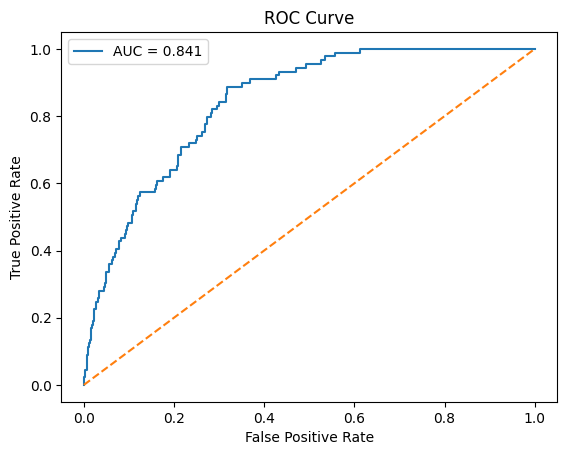

In [ ]:
# ----- ROC CURVE -----
fpr, tpr, roc_thresholds = roc_curve(y_test_model, y_prob)
auc_value = roc_auc_score(y_test_model, y_prob)

print(f"\nAUC-ROC: {auc_value:.3f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#### **EXPLANATION**

From what we can see in the figure, the ROC curve shows an AUC of approximately 0.841, indicating good ability of the model to distinguish between stroke and non-stroke cases. The precision-recall trade-off further emphasizes the impact of threshold selection on model performance.

### PRECISION RECALL CURVE

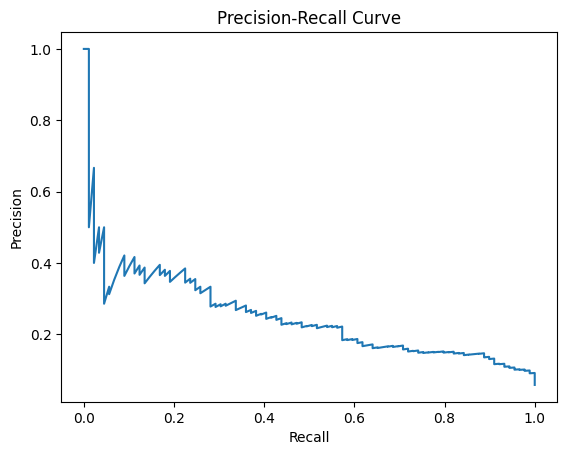

In [ ]:
# ----- PRECISION-RECALL CURVE -----
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_model, y_prob)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

#### **EXPLANATION**

The evaluation of different thresholds demonstrates a clear trade-off between recall and precision. As the threshold increases, precision, specificity, and accuracy improve, while recall decreases significantly. At a threshold of 0.7, recall drops to approximately 0.640, meaning many stroke cases would be missed.

Since the goal is early stroke detection, false negatives are more critical than false positives. Therefore, a lower threshold such as 0.3 is more appropriate, as it prioritises identifying as many high-risk patients as possible.

### ODDS RATIO

In [ ]:
# ----- ODDS RATIOS -----
feature_names = X_model.columns
coefficients = model_weighted.coef_[0]
odds_ratios = np.exp(coefficients)

odds_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

print("\nOdds Ratios:")
print(odds_df.sort_values(by="Odds Ratio", ascending=False).round(3).to_string(index=False))


Odds Ratios:
                       Feature  Coefficient  Odds Ratio
                           age        1.899       6.678
            work_type_children        0.687       1.987
             avg_glucose_level        0.206       1.229
                  hypertension        0.175       1.191
         smoking_status_smokes        0.144       1.155
             work_type_Private        0.094       1.099
                           bmi        0.065       1.067
                 heart_disease        0.064       1.066
          Residence_type_Urban        0.035       1.036
                  gender_Other        0.000       1.000
smoking_status_formerly smoked       -0.026       0.974
       work_type_Self-employed       -0.074       0.929
                   gender_Male       -0.092       0.912
   smoking_status_never smoked       -0.099       0.906
              ever_married_Yes       -0.129       0.879
        work_type_Never_worked       -0.204       0.815


#### **EXPLANATION**

The logistic regression coefficients were converted into odds ratios to make them easier to interpret. An odds ratio greater than 1 means the variable increases the chance of stroke, while a value less than 1 means it decreases the chance.

From the results, age has an odds ratio of 6.678, which shows that as age increases, the likelihood of stroke also increases significantly. This suggests that age is a very important factor in predicting stroke.

Hypertension has an odds ratio of 1.191, meaning that people with hypertension are about 19% more likely to have a stroke compared to those without it.

Overall, these results make sense, as both age and hypertension are well-known risk factors for stroke.

## **QUESTION 3(A): CLUSTERING ANALYSIS**

### CLUSTERING

In [ ]:
# Use the regression-imputed dataset from Q1(c)
cluster_df = df_regression.copy()

# Keep only the required features
cluster_features = cluster_df[[
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi"
]]

print("\nClustering dataset shape:")
print(cluster_features.shape)

print("\nFirst 5 rows:")
print(cluster_features.head())

# ----- Scaling the variables
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_features)



Clustering dataset shape:
(5110, 5)

First 5 rows:
    age  hypertension  heart_disease  avg_glucose_level        bmi
0  67.0             0              1             228.69  36.600000
1  61.0             0              0             202.21  32.457697
2  80.0             0              1             105.92  32.500000
3  49.0             0              0             171.23  34.400000
4  79.0             1              0             174.12  24.000000


### K-MEANS (ELBOW METHOD)

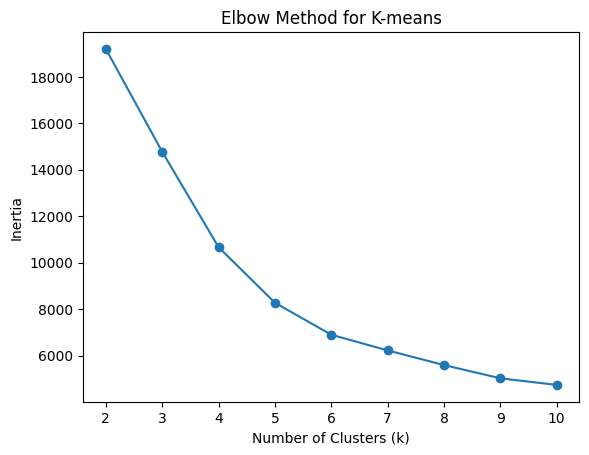

In [ ]:
# ----- K-Means (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure()
plt.plot(list(k_values), inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-means")
plt.show()

### K-MEANS (SILHOUTTE SCORE)

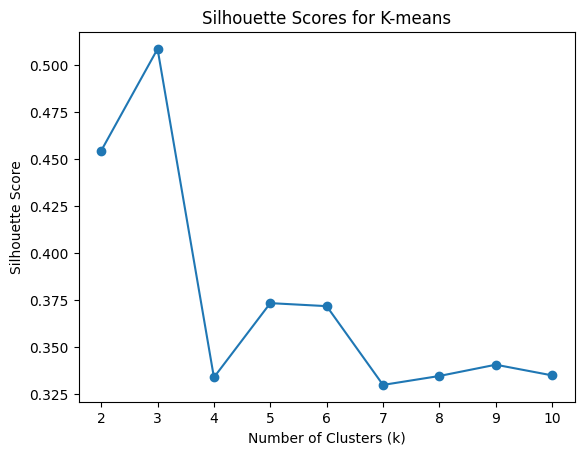

In [ ]:
# ----- K-Means (Silhouette Score)
from sklearn.metrics import silhouette_score

silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    silhouette_values.append(score)

plt.figure()
plt.plot(list(k_values), silhouette_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-means")
plt.show()

In [ ]:
print("\nSilhouette Scores:")
for k, score in zip(k_values, silhouette_values):
    print(f"k = {k}: {score:.3f}")


Silhouette Scores:
k = 2: 0.455
k = 3: 0.509
k = 4: 0.334
k = 5: 0.374
k = 6: 0.372
k = 7: 0.330
k = 8: 0.335
k = 9: 0.341
k = 10: 0.335


### HIERARCHAL CLUSTERING: DENDOGRAM

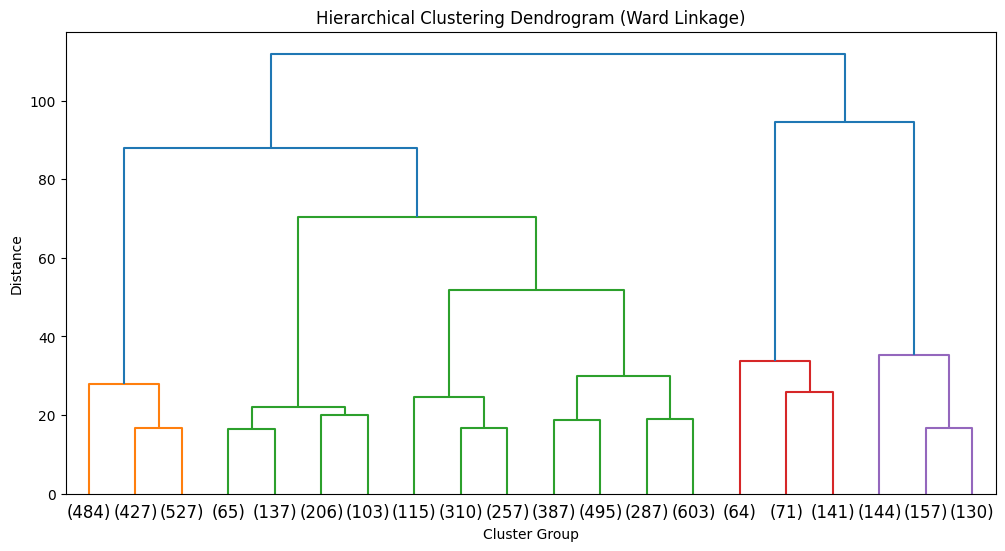

In [ ]:
# ----- Hierarchical Clustering: Dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(cluster_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster Group")
plt.ylabel("Distance")
plt.show()

#### **EXPLANATION**

Clustering was done using both K-means and hierarchical clustering on five variables: age, hypertension, heart disease, average glucose level, and BMI. These variables were standardised first so they are on the same scale.

For K-means, the elbow method and silhouette score were used to decide the number of clusters. The highest silhouette score was at k = 3 (0.509), which means the clusters are well separated. After this, the score drops, especially at k = 4, showing that adding more clusters does not improve the result.

The elbow method shows a similar pattern, where the decrease in inertia starts to slow down after k = 3. This suggests that increasing the number of clusters beyond this point does not add much value.

Hierarchical clustering was also used with Ward linkage. From the dendrogram, there is a clear grouping into a few main clusters, and there is a noticeable jump in distance after around three clusters. This means combining clusters after this point would group less similar data together.

Overall, k = 3 was chosen as the best number of clusters, as it gives a good balance between clear separation and simple interpretation.

## **QUESTION 3(B): FINAL CLUSTERING AND VISUALISATION**

In [ ]:
# ---------- QUESTION 3B FINAL CLUSTERS ----------
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(cluster_scaled)

# Add cluster labels to dataframe
cluster_df["cluster"] = cluster_labels

print("\nCluster counts:")
print(cluster_df["cluster"].value_counts())


Cluster counts:
cluster
0    4400
1     434
2     276
Name: count, dtype: int64


## VISUALISATION 1 AGE VS GLUCOSE

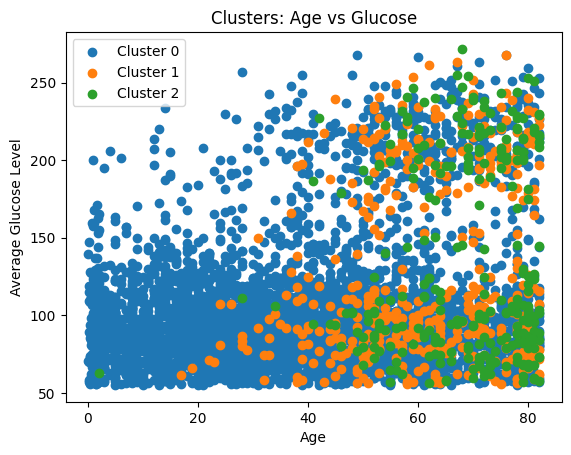

In [ ]:
# ----- Visualization 1 Age vs Glucose
plt.figure()

for cluster in range(3):
    subset = cluster_df[cluster_df["cluster"] == cluster]
    plt.scatter(subset["age"], subset["avg_glucose_level"], label=f"Cluster {cluster}")

plt.xlabel("Age")
plt.ylabel("Average Glucose Level")
plt.title("Clusters: Age vs Glucose")
plt.legend()
plt.show()

## VISUALISATION 2 AGE VS BMI

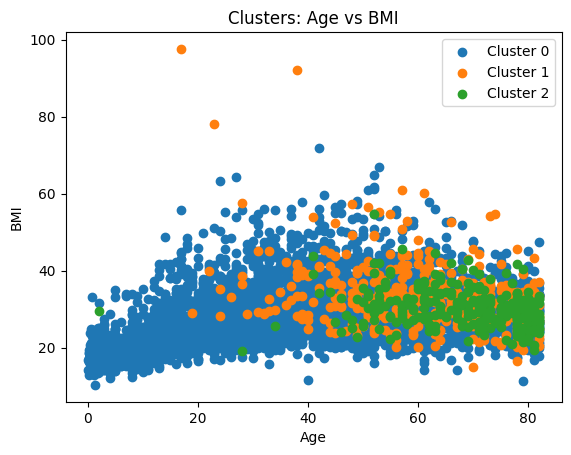

In [ ]:
# ----- Visualisation 2 — Age vs BMI
plt.figure()

for cluster in range(3):
    subset = cluster_df[cluster_df["cluster"] == cluster]
    plt.scatter(subset["age"], subset["bmi"], label=f"Cluster {cluster}")

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Clusters: Age vs BMI")
plt.legend()
plt.show()


## CLUSTER SUMMARY

In [ ]:
# ----- Cluster MEANS
cluster_summary = cluster_df.groupby("cluster")[[
    "age",
    "avg_glucose_level",
    "bmi",
    "hypertension",
    "heart_disease"
]].mean()

print("\nCluster Summary (means):")
print(cluster_summary.round(2))


Cluster Summary (means):
           age  avg_glucose_level    bmi  hypertension  heart_disease
cluster                                                              
0        39.91             102.16  28.44          0.00            0.0
1        61.02             127.09  33.24          1.00            0.0
2        68.19             136.82  30.32          0.23            1.0


### **EXPLANATION**

K-means clustering was applied using k = 3, based on the result from part (a). Each data point was then assigned to one of the three clusters.

The number of observations in each cluster shows that the data is split into three groups of different sizes.

To understand the clusters better, two scatter plots were used. The first plot (age vs average glucose level) shows a clear separation, where one cluster mainly includes older individuals with higher glucose levels, while another cluster contains younger individuals with lower values.

The second plot (age vs BMI) also shows some differences between clusters, but the separation is not as clear compared to the glucose plot.

Overall, the clusters show meaningful groupings based on age, glucose level, and BMI, which suggests that the model is capturing useful patterns in the data.

Cluster 2 has the highest stroke rate, indicating that it represents the highest-risk group.

## **QUESTION 3(C): CLUSTER INTERPRETATION**

In [ ]:
# ----- Stroke rate per cluster (for Q3c) -----
cluster_summary_full = cluster_df.groupby("cluster")[[
    "age",
    "avg_glucose_level",
    "bmi",
    "hypertension",
    "heart_disease",
    "stroke"
]].mean()

print("\nCluster Summary Including Stroke Rate:")
print(cluster_summary_full.round(3))


Cluster Summary Including Stroke Rate:
            age  avg_glucose_level     bmi  hypertension  heart_disease  \
cluster                                                                   
0        39.906            102.158  28.438         0.000            0.0   
1        61.016            127.090  33.243         1.000            0.0   
2        68.188            136.819  30.319         0.232            1.0   

         stroke  
cluster          
0         0.034  
1         0.122  
2         0.170  


### **EXPLANATION**

The final K-means model grouped the patients into three clusters using age, hypertension, heart disease, average glucose level, and BMI. The clusters show clear differences in both health characteristics and stroke risk.

Cluster 0 is the largest group and represents a low-risk population. These individuals are younger, with an average age of 39.91, and have lower glucose levels (102.16). There is no hypertension or heart disease in this group. The stroke rate is only 3.4%, suggesting this is generally a healthier group.

Cluster 1 can be seen as a moderate-risk group. Patients are older, with an average age of 61.02, and have the highest BMI (33.24). All individuals in this cluster have hypertension. The stroke rate is 12.2%, which is noticeably higher than Cluster 0. This suggests that hypertension and higher BMI are linked to increased stroke risk.

Cluster 2 represents the highest-risk group. It includes the oldest patients (average age 68.19) and the highest glucose levels (136.82). All individuals have heart disease, and some also have hypertension. The stroke rate is the highest at 17.0%, showing a strong relationship between these conditions and stroke.

Overall, the clustering separates patients into meaningful groups based on risk. Unlike logistic regression in Question 2, clustering does not directly predict stroke, but it helps identify different types of patients. The clusters still align well with known risk factors such as age, hypertension, heart disease, and glucose levels.

One limitation is that clustering does not use the stroke variable when forming groups, so it does not guarantee prediction accuracy. In addition, K-means assumes simple cluster shapes, which may not capture more complex patterns in the data.

In summary, clustering is useful for identifying higher-risk groups and can support targeted screening or prevention strategies.

# **KEY LEARNING INSIGHTS**

In this assignment, I have used data mining and machine learning methods from the past 7 weeks to predict stroke risk using the given dataset. I first set up my project in PyCharm, where I organised the folder structure and completed all the coding. After that, I used a Jupyter Notebook to present the analysis, results, and visual outputs in a clearer format.

I have started by exploring the data to check for any issues. During this step, I have found missing values in the BMI variable and tested different ways to handle them. In the end, I've chosen regression-based imputation because it kept the relationships between variables better than simpler methods like using the mean or median.

I have also created five new features to improve the model. These included interaction terms, transformations, and grouped categories. These features helped capture patterns that were not as clear in the original variables.

From the data exploration, age appeared to be the strongest predictor of stroke, followed by average glucose level, while BMI showed a weaker relationship. The correlation results showed that most relationships between variables were low. Although the VIF results indicated some moderate multicollinearity, it was not strong enough to remove any variables.

Next, I built three logistic regression models. The basic model had high accuracy but very low recall due to class imbalance, meaning it missed many stroke cases. To improve this, I used class weighting and three resampling methods: undersampling, oversampling, and SMOTE. All three resampling methods improved recall, with random oversampling performing slightly better in my results, although the differences between the methods were small.

I then adjusted the classification threshold to further improve performance. I chose the threshold of 0.3 (tested against 0.2, 0.3, 0.5, and 0.7) because it gave high recall. From my results, this threshold provided a good balance between identifying stroke cases and limiting false positives. This is important in a medical setting, where missing a stroke case is more serious than having false positives.

To better understand the model, I have used odds ratios. These showed that age, hypertension, and glucose levels increase the likelihood of stroke, which matches what is known in real-world medical studies.

Overall, the final model performs well in identifying high-risk patients. Although there is a trade-off between precision and recall, the model is suitable for screening purposes, where the goal is to detect as many stroke cases as possible.

## Key Formulas and Concepts Used from Lectures

The analysis applied several key concepts and formulas introduced in the 6-week lectures.

### Logistic Regression Model
The probability of stroke was modelled using logistic regression:

$$
P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}
$$

This model transforms a linear combination of predictors into a probability using the sigmoid function.

---

### Evaluation Metrics (Confusion Matrix)

The performance of the models was evaluated using the following metrics:

**Accuracy**
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Precision**
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Recall (Sensitivity)**
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Specificity**
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

**F1-score**
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---

### Standardisation (Feature Scaling)

Continuous variables were standardised before modelling:

$$
z = \frac{x - \mu}{\sigma}
$$

---

### Odds Ratio (Model Interpretation)

Logistic regression coefficients were interpreted using odds ratios:

$$
\text{Odds Ratio} = e^{\beta}
$$

---

### Multicollinearity (VIF)

Multicollinearity was assessed using Variance Inflation Factor:

$$
VIF = \frac{1}{1 - R^2}
$$

---

### K-Means Clustering

Clustering was performed by minimising the within-cluster variance:

$$
\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

---

### Silhouette Score

Cluster quality was evaluated using the silhouette score:

$$
s = \frac{b - a}{\max(a, b)}
$$

---

### Additional Note

The AUC-ROC metric was also used to evaluate model performance. This was implemented using external resources, as it was not covered in the lectures.

---

# **END**